In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
#load dataset
DATASET_PATH=r'A:\PROJECTS\archive'
image_paths = []
labels = []
splits = []

for split in ["train", "test"]:
    split_path = os.path.join(DATASET_PATH, split)
    
    for label in ["REAL", "FAKE"]:
        label_path = os.path.join(split_path, label)
        
        for img in os.listdir(label_path):
            image_paths.append(os.path.join(label_path, img))
            labels.append(label)
            splits.append(split)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels,
    "split": splits
})

print(df["label"].value_counts())
print(df["split"].value_counts())
df.head()

label
REAL    60000
FAKE    60000
Name: count, dtype: int64
split
train    100000
test      20000
Name: count, dtype: int64


,image_path,label,split
0,A:\PROJECTS\archive\train\REAL\0000 (10).jpg,REAL,train
1,A:\PROJECTS\archive\train\REAL\0000 (2).jpg,REAL,train
2,A:\PROJECTS\archive\train\REAL\0000 (3).jpg,REAL,train
3,A:\PROJECTS\archive\train\REAL\0000 (4).jpg,REAL,train
4,A:\PROJECTS\archive\train\REAL\0000 (5).jpg,REAL,train


In [4]:
#take subset of train set
df_train = df[df["split"] == "train"]

df_train_subset = df_train.groupby("label").apply(
    lambda x: x.sample(2500, random_state=42)
).reset_index(drop=True)

print("Train subset distribution:")
print(df_train_subset["label"].value_counts())

Train subset distribution:
label
FAKE    2500
REAL    2500
Name: count, dtype: int64


C:\Users\akash\AppData\Local\Temp\ipykernel_12964\2794083.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_subset = df_train.groupby("label").apply(


In [5]:
#take subset of test
df_test = df[df["split"] == "test"]

df_test_subset = df_test.groupby("label").apply(
    lambda x: x.sample(1000, random_state=42)
).reset_index(drop=True)

print("Test subset distribution:")
print(df_test_subset["label"].value_counts())

Test subset distribution:
label
FAKE    1000
REAL    1000
Name: count, dtype: int64


C:\Users\akash\AppData\Local\Temp\ipykernel_12964\3457897849.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_subset = df_test.groupby("label").apply(


In [6]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [7]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [15]:

from torchvision import transforms

IMAGE_SIZE = 224

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [9]:
from torch.utils.data import Dataset
from PIL import Image

class CIFAKEDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        self.label_map = {"REAL": 0, "FAKE": 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        label = self.label_map[self.df.iloc[idx]["label"]]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
#create dataset objects
train_dataset = CIFAKEDataset(df_train_subset, transform=train_transform)
test_dataset = CIFAKEDataset(df_test_subset, transform=test_transform)

In [11]:
#create dataloaders
from torch.utils.data import DataLoader

BATCH_SIZE = 32 if torch.cuda.is_available() else 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Batch size:", BATCH_SIZE)

Batch size: 16


In [12]:
#setup resnet
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)

# If GPU available → train full model
# If CPU → freeze backbone for speed
if torch.cuda.is_available():
    print("Training full model (GPU mode)")
else:
    print("Freezing backbone (CPU mode)")
    for param in model.parameters():
        param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\akash/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


c:\Users\akash\anaconda3\envs\anpr_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\akash\anaconda3\envs\anpr_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:48<00:00, 963kB/s] 

Freezing backbone (CPU mode)


In [13]:
criterion = nn.CrossEntropyLoss()

if torch.cuda.is_available():
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
else:
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

In [14]:
#training
EPOCHS = 5 if torch.cuda.is_available() else 3

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Loss: {running_loss/len(train_loader):.4f} "
          f"Train Accuracy: {train_acc:.4f}")

Epoch [1/3] Loss: 0.5225 Train Accuracy: 0.7388
Epoch [2/3] Loss: 0.4080 Train Accuracy: 0.8158
Epoch [3/3] Loss: 0.3919 Train Accuracy: 0.8238


In [19]:
!pip install scikit-learn seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [22]:
print(classification_report(all_labels, all_preds, target_names=["Real", "Fake"]))

              precision    recall  f1-score   support

        Real       0.91      0.69      0.79      1000
        Fake       0.75      0.93      0.83      1000

    accuracy                           0.81      2000
   macro avg       0.83      0.81      0.81      2000
weighted avg       0.83      0.81      0.81      2000



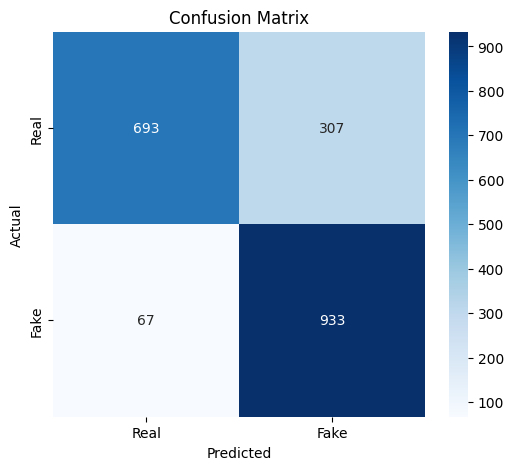

In [23]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Grad-CAM Explainability

In [26]:
!pip install grad-cam

     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     ---- ----------------------------------- 0.8/7.8 MB 6.6 MB/s eta 0:00:02
     --------- ------------------------------ 1.8/7.8 MB 4.6 MB/s eta 0:00:02
     ------------- -------------------------- 2.6/7.8 MB 4.3 MB/s eta 0:00:02
     ---------------- ----------------------- 3.1/7.8 MB 3.7 MB/s eta 0:00:02
     --------------------- ------------------ 4.2/7.8 MB 3.9 MB/s eta 0:00:01
     ------------------------- -------------- 5.0/7.8 MB 3.9 MB/s eta 0:00:01
     ----------------------------- ---------- 5.8/7.8 MB 3.9 MB/s eta 0:00:01
     --------------------------------- ------ 6.6/7.8 MB 3.9 MB/s eta 0:00:01
     ------------------------------------- -- 7.3/7.8 MB 3.9 MB/s eta 0:00:01
     ---------------------------------------- 7.8/7.8 MB 3.8 MB/s  0:00:02
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  G

In [27]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np

In [31]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [32]:
target_layers = [model.layer4[-1]]

In [33]:
image, label = test_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

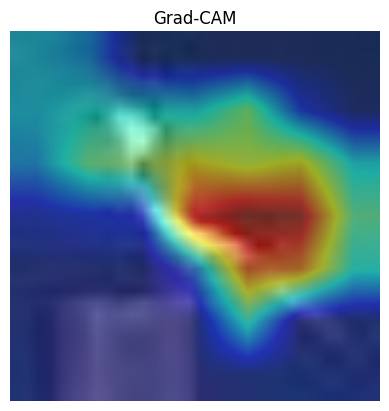

In [ ]:
#  enable gradients
torch.set_grad_enabled(True)

model.eval()

# select image
image, label = test_dataset[0]

input_tensor = image.unsqueeze(0).to(device)
input_tensor.requires_grad = True

# target layer
target_layers = [model.layer4[-1]]

# Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)

#  use predicted class
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()

targets = [ClassifierOutputTarget(pred_class)]

# generate heatmap
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0]

# visualize
rgb_img = image.permute(1,2,0).cpu().numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

import matplotlib.pyplot as plt
plt.imshow(visualization)
plt.axis("off")
plt.title("Grad-CAM")
plt.show()

Find High Confidence Fake Image

In [37]:
high_conf_fake = None

model.eval()

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

    for i in range(len(labels)):
        if labels[i] == 1 and preds[i] == 1 and probs[i][1] > 0.95:
            high_conf_fake = images[i]
            break

    if high_conf_fake is not None:
        break

print("Selected fake image.")

Selected fake image.


In [38]:
def get_confidence(img):
    model.eval()
    with torch.no_grad():
        output = model(img.unsqueeze(0))
        prob = torch.softmax(output, dim=1)
        return prob.cpu().numpy()

print("Original Confidence:", get_confidence(high_conf_fake)) 

Original Confidence: [[0.00166047 0.99833953]]


FGSM Attack (Strong & Clean)

FGSM = Fast Gradient Sign Method
Introduced in adversarial research by
Ian Goodfellow.

In [39]:
epsilon = 0.03  # strength of attack

high_conf_fake.requires_grad = True

output = model(high_conf_fake.unsqueeze(0))
loss = torch.nn.functional.cross_entropy(output, torch.tensor([0]).to(device))
# We target class 0 (Real) to flip prediction

model.zero_grad()
loss.backward()

data_grad = high_conf_fake.grad.data

# FGSM formula
perturbed_image = high_conf_fake + epsilon * data_grad.sign()
perturbed_image = torch.clamp(perturbed_image, 0, 1)

print("After Attack Confidence:", get_confidence(perturbed_image))

After Attack Confidence: [[0.5645659  0.43543413]]


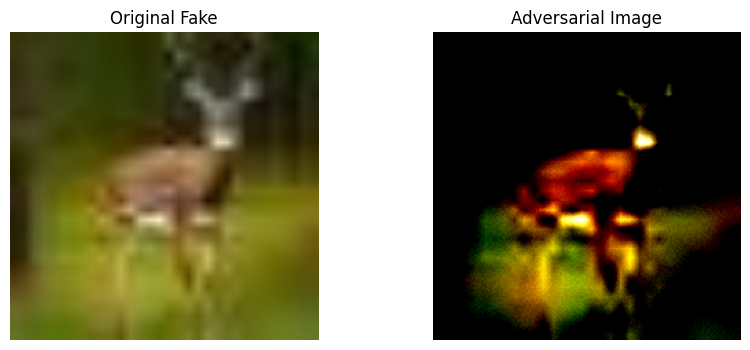

In [42]:
#Visualize Before vs After
plt.figure(figsize=(10,4))

# Original image
plt.subplot(1,2,1)
orig = high_conf_fake.detach().cpu().permute(1,2,0).numpy()
orig = (orig - orig.min()) / (orig.max() - orig.min())
plt.imshow(orig)
plt.title("Original Fake")
plt.axis("off")

# Adversarial image
plt.subplot(1,2,2)
adv = perturbed_image.detach().cpu().permute(1,2,0).numpy()
adv = (adv - adv.min()) / (adv.max() - adv.min())
plt.imshow(adv)
plt.title("Adversarial Image")
plt.axis("off")

plt.show()

Compare Grad-CAM Before vs After Attack

In [43]:
def generate_gradcam(img, model, device):
    model.eval()
    torch.set_grad_enabled(True)

    input_tensor = img.unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    # target layer (correct for your ResNet)
    target_layers = [model.layer4[-1]]

    cam = GradCAM(model=model, target_layers=target_layers)

    # predicted class
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()

    targets = [ClassifierOutputTarget(pred_class)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    return grayscale_cam

In [44]:
cam_original = generate_gradcam(high_conf_fake.detach().cpu(), model, device)
cam_adv = generate_gradcam(perturbed_image.detach().cpu(), model, device)

In [45]:
orig_img = high_conf_fake.detach().cpu().permute(1,2,0).numpy()
orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())

adv_img = perturbed_image.detach().cpu().permute(1,2,0).numpy()
adv_img = (adv_img - adv_img.min()) / (adv_img.max() - adv_img.min())

In [46]:
vis_orig = show_cam_on_image(orig_img, cam_original, use_rgb=True)
vis_adv = show_cam_on_image(adv_img, cam_adv, use_rgb=True)

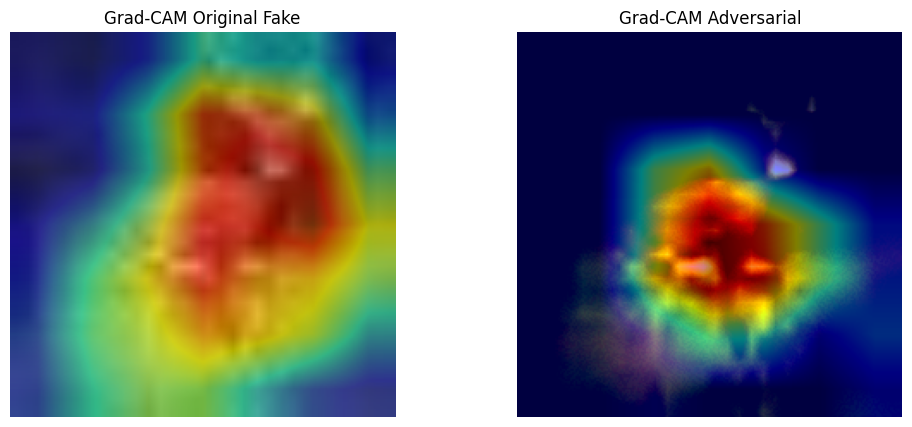

In [47]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(vis_orig)
plt.title("Grad-CAM Original Fake")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(vis_adv)
plt.title("Grad-CAM Adversarial")
plt.axis("off")

plt.show()

Improve Detector

FGSM adversarial examples during training

Instead of training only on normal images, we train on:

Original + adversarial images.

This teaches the model to resist attacks.

In [48]:
def fgsm_attack(model, images, labels, epsilon=0.03):
    images = images.clone().detach().to(device)
    labels = labels.to(device)

    images.requires_grad = True

    outputs = model(images)
    loss = torch.nn.functional.cross_entropy(outputs, labels)

    model.zero_grad()
    loss.backward()

    data_grad = images.grad.data

    adv_images = images + epsilon * data_grad.sign()
    adv_images = torch.clamp(adv_images, 0, 1)

    return adv_images.detach()

Modify your training loop

We will now train on both:

✔ Clean images
✔ FGSM attacked images

This is the key improvement.

In [ ]:
#New adversarial training loop
num_epochs = 3  # you can increase later

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # generate adversarial images
        adv_images = fgsm_attack(model, images, labels, epsilon=0.03)

        # combine clean + adversarial
        combined_images = torch.cat([images, adv_images])
        combined_labels = torch.cat([labels, labels])

        optimizer.zero_grad()

        outputs = model(combined_images)
        loss = criterion(outputs, combined_labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")